# Airline Flight Data Analysis & Fare Insights

**Project:** Airline Flight Data Analysis & Fare Insights  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

This notebook contains the project work for **data understanding, data cleaning, Python EDA, and visualizations**. SQL and Tableau will be handled separately.

## 1. Import Libraries

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [131]:
airline_flight = pd.read_excel("/content/airline_flight.xlsx")
airline_flight.head()

,Flight_ID,Airline,Flight_Number,Source,Destination,Journey_Date,Booking_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Class,Ticket_Price,Seats_Available,Aircraft_Type,Booking_Channel,Passenger_Type,Cancellation_Status
0,FL100000,AirAsia India,UK-6041,Delhi,Mumbai,2026-02-02,2026-01-12,16:30:00,23:49:00,7h 19m,2 Stops,Economy,12240.0,29.0,Boeing 737,Airline Website,Business,Completed
1,FL100001,IndiGo,UK-6017,Bangalore,Pune,2026-10-09,2026-09-08,02:07:00,NaN,2h 24m,1 Stop,Economy,3840.0,94.0,Boeing 787,Online Travel Portal,Leisure,Completed
2,FL100002,SpiceJet,NaN,Ahmedabad,Delhi,2026-08-27,2026-06-11,13:45:00,04:01:00,14h 16m,Non-stop,Economy,12290.0,4.0,Airbus A320,Airline Website,Student,Completed
3,FL100003,AirAsia India,UK-5006,Chennai,Ahmedabad,2026-06-09,2026-05-30,05:10:00,18:47:00,13h 37m,1 Stop,Business,29800.0,21.0,Airbus A321,Online Travel Portal,Student,Completed
4,FL100004,AirAsia India,SG-4652,Mumbai,Delhi,2026-06-07,2026-05-28,11:45:00,17:50:00,6h 5m,Non-stop,Economy,10680.0,46.0,Boeing 787,Online Travel Portal,Leisure,Completed


## 3. Initial Data Understanding

In [132]:
airline_flight.shape

(30000, 18)

In [133]:
airline_flight.columns

Index(['Flight_ID', 'Airline', 'Flight_Number', 'Source', 'Destination',
       'Journey_Date', 'Booking_Date', 'Departure_Time', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Class', 'Ticket_Price', 'Seats_Available',
       'Aircraft_Type', 'Booking_Channel', 'Passenger_Type',
       'Cancellation_Status'],
      dtype='object')

In [134]:
airline_flight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Flight_ID            30000 non-null  object        
 1   Airline              29554 non-null  object        
 2   Flight_Number        29701 non-null  object        
 3   Source               29637 non-null  object        
 4   Destination          29634 non-null  object        
 5   Journey_Date         29699 non-null  datetime64[ns]
 6   Booking_Date         29554 non-null  datetime64[ns]
 7   Departure_Time       29459 non-null  object        
 8   Arrival_Time         29458 non-null  object        
 9   Duration             29549 non-null  object        
 10  Total_Stops          29639 non-null  object        
 11  Class                29697 non-null  object        
 12  Ticket_Price         29407 non-null  float64       
 13  Seats_Available      29549 non-

In [135]:
airline_flight.describe(include="all")

,Flight_ID,Airline,Flight_Number,Source,Destination,Journey_Date,Booking_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Class,Ticket_Price,Seats_Available,Aircraft_Type,Booking_Channel,Passenger_Type,Cancellation_Status
count,30000,29554,29701,29637,29634,29699,29554,29459,29458,29549,29639,29697,29407.000000,29549.000000,29638,29554,29640,29698
unique,29700,12,23083,10,10,NaN,NaN,1440,1440,825,3,6,NaN,NaN,5,8,4,2
top,FL117535,IndiGo,AI-1200,Ahmedabad,Hyderabad,NaN,NaN,17:01:00,23:13:00,9h 23m,Non-stop,Economy,NaN,NaN,Airbus A350,Airline Website,Student,Completed
freq,2,8831,6,3051,3004,NaN,NaN,39,34,54,16299,24943,NaN,NaN,6029,7425,7498,27384
mean,NaN,NaN,NaN,NaN,NaN,2026-06-30 23:53:12.713559296,2026-05-16 19:00:20.707856896,NaN,NaN,NaN,NaN,NaN,11018.844153,90.041592,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,2026-01-01 00:00:00,2025-10-04 00:00:00,NaN,NaN,NaN,NaN,NaN,1300.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,2026-04-01 00:00:00,2026-02-15 00:00:00,NaN,NaN,NaN,NaN,NaN,6320.000000,44.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,2026-07-01 00:00:00,2026-05-16 00:00:00,NaN,NaN,NaN,NaN,NaN,10000.000000,90.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,2026-09-30 00:00:00,2026-08-15 00:00:00,NaN,NaN,NaN,NaN,NaN,13450.000000,136.000000,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,2026-12-30 00:00:00,2026-12-29 00:00:00,NaN,NaN,NaN,NaN,NaN,34180.000000,180.000000,NaN,NaN,NaN,NaN


In [136]:
airline_flight.head()

,Flight_ID,Airline,Flight_Number,Source,Destination,Journey_Date,Booking_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Class,Ticket_Price,Seats_Available,Aircraft_Type,Booking_Channel,Passenger_Type,Cancellation_Status
0,FL100000,AirAsia India,UK-6041,Delhi,Mumbai,2026-02-02,2026-01-12,16:30:00,23:49:00,7h 19m,2 Stops,Economy,12240.0,29.0,Boeing 737,Airline Website,Business,Completed
1,FL100001,IndiGo,UK-6017,Bangalore,Pune,2026-10-09,2026-09-08,02:07:00,NaN,2h 24m,1 Stop,Economy,3840.0,94.0,Boeing 787,Online Travel Portal,Leisure,Completed
2,FL100002,SpiceJet,NaN,Ahmedabad,Delhi,2026-08-27,2026-06-11,13:45:00,04:01:00,14h 16m,Non-stop,Economy,12290.0,4.0,Airbus A320,Airline Website,Student,Completed
3,FL100003,AirAsia India,UK-5006,Chennai,Ahmedabad,2026-06-09,2026-05-30,05:10:00,18:47:00,13h 37m,1 Stop,Business,29800.0,21.0,Airbus A321,Online Travel Portal,Student,Completed
4,FL100004,AirAsia India,SG-4652,Mumbai,Delhi,2026-06-07,2026-05-28,11:45:00,17:50:00,6h 5m,Non-stop,Economy,10680.0,46.0,Boeing 787,Online Travel Portal,Leisure,Completed


In [137]:
airline_flight.tail()

,Flight_ID,Airline,Flight_Number,Source,Destination,Journey_Date,Booking_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Class,Ticket_Price,Seats_Available,Aircraft_Type,Booking_Channel,Passenger_Type,Cancellation_Status
29995,FL104301,SpiceJet,I5-510,Ahmedabad,Delhi,2026-08-27,2026-06-10,17:58:00,05:05:00,11h 7m,Non-stop,Business,27690.0,28.0,Airbus A320,NaN,Family,Completed
29996,FL106759,Vistara,6E-2019,Bangalore,Pune,2026-12-14,2026-09-24,02:20:00,12:41:00,10h 21m,Non-stop,Economy,10700.0,14.0,Airbus A350,Airline Website,Student,NaN
29997,FL113362,IndiGo,AI-4700,Delhi,Pune,2026-02-21,2026-01-29,05:27:00,14:50:00,9h 23m,1 Stop,Business,26560.0,53.0,Boeing 787,Airline Website,Business,Completed
29998,FL106442,SpiceJet,G8-5741,Kolkata,Ahmedabad,2026-07-16,2026-05-02,09:41:00,15:02:00,5h 21m,Non-stop,Economy,8380.0,101.0,Airbus A350,Travel Agent,Leisure,Completed
29999,FL128452,Vistara,G8-8886,Bangalore,Hyderabad,2026-10-06,2026-08-12,16:12:00,20:23:00,4h 11m,Non-stop,Economy,3610.0,80.0,Airbus A321,Travel Agent,Family,Completed


## 4. Data Quality Checks

In [138]:
airline_flight.isnull().sum()

,0
Flight_ID,0
Airline,446
Flight_Number,299
Source,363
Destination,366
Journey_Date,301
Booking_Date,446
Departure_Time,541
Arrival_Time,542
Duration,451


In [139]:
airline_flight.isnull().sum().sum()

np.int64(6933)

In [140]:
airline_flight.duplicated().sum()

np.int64(298)

In [141]:
airline_flight.nunique()

,0
Flight_ID,29700
Airline,12
Flight_Number,23083
Source,10
Destination,10
Journey_Date,364
Booking_Date,452
Departure_Time,1440
Arrival_Time,1440
Duration,825


In [142]:
airline_flight[airline_flight["Ticket_Price"] < 0]

,Flight_ID,Airline,Flight_Number,Source,Destination,Journey_Date,Booking_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Class,Ticket_Price,Seats_Available,Aircraft_Type,Booking_Channel,Passenger_Type,Cancellation_Status


In [143]:
airline_flight[airline_flight["Seats_Available"] < 0]

,Flight_ID,Airline,Flight_Number,Source,Destination,Journey_Date,Booking_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Class,Ticket_Price,Seats_Available,Aircraft_Type,Booking_Channel,Passenger_Type,Cancellation_Status


## 5. Create Working Copy

In [144]:
cleaned_airline_flight = airline_flight.copy()
cleaned_airline_flight


,Flight_ID,Airline,Flight_Number,Source,Destination,Journey_Date,Booking_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Class,Ticket_Price,Seats_Available,Aircraft_Type,Booking_Channel,Passenger_Type,Cancellation_Status
0,FL100000,AirAsia India,UK-6041,Delhi,Mumbai,2026-02-02,2026-01-12,16:30:00,23:49:00,7h 19m,2 Stops,Economy,12240.0,29.0,Boeing 737,Airline Website,Business,Completed
1,FL100001,IndiGo,UK-6017,Bangalore,Pune,2026-10-09,2026-09-08,02:07:00,NaN,2h 24m,1 Stop,Economy,3840.0,94.0,Boeing 787,Online Travel Portal,Leisure,Completed
2,FL100002,SpiceJet,NaN,Ahmedabad,Delhi,2026-08-27,2026-06-11,13:45:00,04:01:00,14h 16m,Non-stop,Economy,12290.0,4.0,Airbus A320,Airline Website,Student,Completed
3,FL100003,AirAsia India,UK-5006,Chennai,Ahmedabad,2026-06-09,2026-05-30,05:10:00,18:47:00,13h 37m,1 Stop,Business,29800.0,21.0,Airbus A321,Online Travel Portal,Student,Completed
4,FL100004,AirAsia India,SG-4652,Mumbai,Delhi,2026-06-07,2026-05-28,11:45:00,17:50:00,6h 5m,Non-stop,Economy,10680.0,46.0,Boeing 787,Online Travel Portal,Leisure,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,FL104301,SpiceJet,I5-510,Ahmedabad,Delhi,2026-08-27,2026-06-10,17:58:00,05:05:00,11h 7m,Non-stop,Business,27690.0,28.0,Airbus A320,NaN,Family,Completed
29996,FL106759,Vistara,6E-2019,Bangalore,Pune,2026-12-14,2026-09-24,02:20:00,12:41:00,10h 21m,Non-stop,Economy,10700.0,14.0,Airbus A350,Airline Website,Student,NaN
29997,FL113362,IndiGo,AI-4700,Delhi,Pune,2026-02-21,2026-01-29,05:27:00,14:50:00,9h 23m,1 Stop,Business,26560.0,53.0,Boeing 787,Airline Website,Business,Completed
29998,FL106442,SpiceJet,G8-5741,Kolkata,Ahmedabad,2026-07-16,2026-05-02,09:41:00,15:02:00,5h 21m,Non-stop,Economy,8380.0,101.0,Airbus A350,Travel Agent,Leisure,Completed


## 6. Data Cleaning

### 6.1 Remove Duplicate Rows

In [145]:
cleaned_airline_flight = cleaned_airline_flight.drop_duplicates()
print("Duplicate rows:", cleaned_airline_flight.duplicated().sum())

Duplicate rows: 0


### 6.2 Check Column Names

In [146]:
cleaned_airline_flight.columns

Index(['Flight_ID', 'Airline', 'Flight_Number', 'Source', 'Destination',
       'Journey_Date', 'Booking_Date', 'Departure_Time', 'Arrival_Time',
       'Duration', 'Total_Stops', 'Class', 'Ticket_Price', 'Seats_Available',
       'Aircraft_Type', 'Booking_Channel', 'Passenger_Type',
       'Cancellation_Status'],
      dtype='object')

### 6.3 Standardize Text Columns

In [147]:
cleaned_airline_flight = airline_flight.copy()
cleaned_airline_flight

,Flight_ID,Airline,Flight_Number,Source,Destination,Journey_Date,Booking_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Class,Ticket_Price,Seats_Available,Aircraft_Type,Booking_Channel,Passenger_Type,Cancellation_Status
0,FL100000,AirAsia India,UK-6041,Delhi,Mumbai,2026-02-02,2026-01-12,16:30:00,23:49:00,7h 19m,2 Stops,Economy,12240.0,29.0,Boeing 737,Airline Website,Business,Completed
1,FL100001,IndiGo,UK-6017,Bangalore,Pune,2026-10-09,2026-09-08,02:07:00,NaN,2h 24m,1 Stop,Economy,3840.0,94.0,Boeing 787,Online Travel Portal,Leisure,Completed
2,FL100002,SpiceJet,NaN,Ahmedabad,Delhi,2026-08-27,2026-06-11,13:45:00,04:01:00,14h 16m,Non-stop,Economy,12290.0,4.0,Airbus A320,Airline Website,Student,Completed
3,FL100003,AirAsia India,UK-5006,Chennai,Ahmedabad,2026-06-09,2026-05-30,05:10:00,18:47:00,13h 37m,1 Stop,Business,29800.0,21.0,Airbus A321,Online Travel Portal,Student,Completed
4,FL100004,AirAsia India,SG-4652,Mumbai,Delhi,2026-06-07,2026-05-28,11:45:00,17:50:00,6h 5m,Non-stop,Economy,10680.0,46.0,Boeing 787,Online Travel Portal,Leisure,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,FL104301,SpiceJet,I5-510,Ahmedabad,Delhi,2026-08-27,2026-06-10,17:58:00,05:05:00,11h 7m,Non-stop,Business,27690.0,28.0,Airbus A320,NaN,Family,Completed
29996,FL106759,Vistara,6E-2019,Bangalore,Pune,2026-12-14,2026-09-24,02:20:00,12:41:00,10h 21m,Non-stop,Economy,10700.0,14.0,Airbus A350,Airline Website,Student,NaN
29997,FL113362,IndiGo,AI-4700,Delhi,Pune,2026-02-21,2026-01-29,05:27:00,14:50:00,9h 23m,1 Stop,Business,26560.0,53.0,Boeing 787,Airline Website,Business,Completed
29998,FL106442,SpiceJet,G8-5741,Kolkata,Ahmedabad,2026-07-16,2026-05-02,09:41:00,15:02:00,5h 21m,Non-stop,Economy,8380.0,101.0,Airbus A350,Travel Agent,Leisure,Completed


In [148]:
cleaned_airline_flight["Airline"] = cleaned_airline_flight["Airline"].astype("string").str.strip()

cleaned_airline_flight["Airline"]




,Airline
0,AirAsia India
1,IndiGo
2,SpiceJet
3,AirAsia India
4,AirAsia India
...,...
29995,SpiceJet
29996,Vistara
29997,IndiGo
29998,SpiceJet


In [149]:
cleaned_airline_flight["Source"] = cleaned_airline_flight["Source"].astype("string").str.strip()
cleaned_airline_flight["Source"]

,Source
0,Delhi
1,Bangalore
2,Ahmedabad
3,Chennai
4,Mumbai
...,...
29995,Ahmedabad
29996,Bangalore
29997,Delhi
29998,Kolkata


In [150]:

cleaned_airline_flight["Destination"] = cleaned_airline_flight["Destination"].astype("string").str.strip()

cleaned_airline_flight["Destination"]

,Destination
0,Mumbai
1,Pune
2,Delhi
3,Ahmedabad
4,Delhi
...,...
29995,Delhi
29996,Pune
29997,Pune
29998,Ahmedabad


In [151]:

cleaned_airline_flight["Class"] = cleaned_airline_flight["Class"].astype("string").str.strip().str.title()

cleaned_airline_flight["Class"]

,Class
0,Economy
1,Economy
2,Economy
3,Business
4,Economy
...,...
29995,Business
29996,Economy
29997,Business
29998,Economy


In [152]:

cleaned_airline_flight["Aircraft_Type"] = cleaned_airline_flight["Aircraft_Type"].astype("string").str.strip()
cleaned_airline_flight["Aircraft_Type"]

,Aircraft_Type
0,Boeing 737
1,Boeing 787
2,Airbus A320
3,Airbus A321
4,Boeing 787
...,...
29995,Airbus A320
29996,Airbus A350
29997,Boeing 787
29998,Airbus A350


In [153]:
cleaned_airline_flight["Booking_Channel"] = cleaned_airline_flight["Booking_Channel"].astype("string").str.strip()
cleaned_airline_flight["Booking_Channel"]

,Booking_Channel
0,Airline Website
1,Online Travel Portal
2,Airline Website
3,Online Travel Portal
4,Online Travel Portal
...,...
29995,<NA>
29996,Airline Website
29997,Airline Website
29998,Travel Agent


In [154]:
cleaned_airline_flight["Passenger_Type"] = cleaned_airline_flight["Passenger_Type"].astype("string").str.strip()
cleaned_airline_flight["Passenger_Type"]

,Passenger_Type
0,Business
1,Leisure
2,Student
3,Student
4,Leisure
...,...
29995,Family
29996,Student
29997,Business
29998,Leisure


In [155]:
cleaned_airline_flight["Cancellation_Status"] = cleaned_airline_flight["Cancellation_Status"].astype("string").str.strip()
cleaned_airline_flight["Cancellation_Status"]

,Cancellation_Status
0,Completed
1,Completed
2,Completed
3,Completed
4,Completed
...,...
29995,Completed
29996,<NA>
29997,Completed
29998,Completed


### 6.4 Convert Date Columns

In [156]:
cleaned_airline_flight["Journey_Date"] = pd.to_datetime(
    cleaned_airline_flight["Journey_Date"],
    errors="coerce"
)

cleaned_airline_flight["Booking_Date"] = pd.to_datetime(
    cleaned_airline_flight["Booking_Date"],
    errors="coerce"
)

### 6.5 Check Data Types

In [157]:
cleaned_airline_flight.dtypes

,0
Flight_ID,object
Airline,string[python]
Flight_Number,object
Source,string[python]
Destination,string[python]
Journey_Date,datetime64[ns]
Booking_Date,datetime64[ns]
Departure_Time,object
Arrival_Time,object
Duration,object


### 6.6 Handle Missing Values

In [158]:
# Categorical columns: fill with mode

cleaned_airline_flight["Airline"] = cleaned_airline_flight["Airline"].fillna(
    cleaned_airline_flight["Airline"].mode()[0]
)

cleaned_airline_flight["Source"] = cleaned_airline_flight["Source"].fillna(
    cleaned_airline_flight["Source"].mode()[0]
)

cleaned_airline_flight["Destination"] = cleaned_airline_flight["Destination"].fillna(
    cleaned_airline_flight["Destination"].mode()[0]
)

cleaned_airline_flight["Flight_Number"] = cleaned_airline_flight["Flight_Number"].fillna(
    cleaned_airline_flight["Flight_Number"].mode()[0]
)

cleaned_airline_flight["Departure_Time"] = cleaned_airline_flight["Departure_Time"].fillna(
    cleaned_airline_flight["Departure_Time"].mode()[0]
)

cleaned_airline_flight["Arrival_Time"] = cleaned_airline_flight["Arrival_Time"].fillna(
    cleaned_airline_flight["Arrival_Time"].mode()[0]
)

cleaned_airline_flight["Total_Stops"] = cleaned_airline_flight["Total_Stops"].fillna(
    cleaned_airline_flight["Total_Stops"].mode()[0]
)

cleaned_airline_flight["Class"] = cleaned_airline_flight["Class"].fillna(
    cleaned_airline_flight["Class"].mode()[0]
)

cleaned_airline_flight["Aircraft_Type"] = cleaned_airline_flight["Aircraft_Type"].fillna(
    cleaned_airline_flight["Aircraft_Type"].mode()[0]
)

cleaned_airline_flight["Booking_Channel"] = cleaned_airline_flight["Booking_Channel"].fillna(
    cleaned_airline_flight["Booking_Channel"].mode()[0]
)

cleaned_airline_flight["Passenger_Type"] = cleaned_airline_flight["Passenger_Type"].fillna(
    cleaned_airline_flight["Passenger_Type"].mode()[0]
)

cleaned_airline_flight["Cancellation_Status"] = cleaned_airline_flight["Cancellation_Status"].fillna(
    cleaned_airline_flight["Cancellation_Status"].mode()[0]
)

In [159]:
# Numeric columns: fill with median

cleaned_airline_flight["Ticket_Price"] = cleaned_airline_flight["Ticket_Price"].fillna(
    cleaned_airline_flight["Ticket_Price"].median()
)

cleaned_airline_flight["Seats_Available"] = cleaned_airline_flight["Seats_Available"].fillna(
    cleaned_airline_flight["Seats_Available"].median()
)

In [160]:
# Date columns: fill missing values with median date

cleaned_airline_flight["Journey_Date"] = cleaned_airline_flight["Journey_Date"].fillna(
    cleaned_airline_flight["Journey_Date"].dropna().median()
)

cleaned_airline_flight["Booking_Date"] = cleaned_airline_flight["Booking_Date"].fillna(
    cleaned_airline_flight["Booking_Date"].dropna().median()
)

### 6.7 Convert Duration into Minutes

In [161]:
def duration_to_minutes(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()
    hours = 0
    minutes = 0

    if "h" in value:
        hours = int(value.split("h")[0].strip())

    if "m" in value:
        minute_part = value.split("h")[-1].replace("m", "").strip()
        if minute_part:
            minutes = int(minute_part)

    return hours * 60 + minutes

cleaned_airline_flight["Duration_Minutes"] = (
    cleaned_airline_flight["Duration"].apply(duration_to_minutes)
)

cleaned_airline_flight["Duration_Minutes"] = cleaned_airline_flight[
    "Duration_Minutes"
].fillna(cleaned_airline_flight["Duration_Minutes"].median())

### 6.8 Convert Number of Stops into Numeric Form

In [162]:
stop_mapping = {
    "Non-stop": 0,
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "1 Stop": 1,
    "2 Stops": 2
}

cleaned_airline_flight["Total_Stops_Num"] = (
    cleaned_airline_flight["Total_Stops"].map(stop_mapping)
)

cleaned_airline_flight["Total_Stops_Num"] = cleaned_airline_flight[
    "Total_Stops_Num"
].fillna(cleaned_airline_flight["Total_Stops_Num"].median())

### 6.9 Final Cleaning Validation

In [163]:
print("Shape:", cleaned_airline_flight.shape)
print("Total missing values:", cleaned_airline_flight.isnull().sum().sum())
print("Total duplicate rows:", cleaned_airline_flight.duplicated().sum())

Shape: (30000, 20)
Total missing values: 451
Total duplicate rows: 300


In [164]:
cleaned_airline_flight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Flight_ID            30000 non-null  object        
 1   Airline              30000 non-null  string        
 2   Flight_Number        30000 non-null  object        
 3   Source               30000 non-null  string        
 4   Destination          30000 non-null  string        
 5   Journey_Date         30000 non-null  datetime64[ns]
 6   Booking_Date         30000 non-null  datetime64[ns]
 7   Departure_Time       30000 non-null  object        
 8   Arrival_Time         30000 non-null  object        
 9   Duration             29549 non-null  object        
 10  Total_Stops          30000 non-null  object        
 11  Class                30000 non-null  string        
 12  Ticket_Price         30000 non-null  float64       
 13  Seats_Available      30000 non-

In [165]:
cleaned_airline_flight.describe(include="all")

,Flight_ID,Airline,Flight_Number,Source,Destination,Journey_Date,Booking_Date,Departure_Time,Arrival_Time,Duration,Total_Stops,Class,Ticket_Price,Seats_Available,Aircraft_Type,Booking_Channel,Passenger_Type,Cancellation_Status,Duration_Minutes,Total_Stops_Num
count,30000,30000,30000,30000,30000,30000,30000,30000,30000,29549,30000,30000,30000.000000,30000.000000,30000,30000,30000,30000,30000.000000,30000.00000
unique,29700,6,23083,10,10,NaN,NaN,1440,1440,825,3,3,NaN,NaN,5,4,4,2,NaN,NaN
top,FL117535,IndiGo,AI-1200,Ahmedabad,Hyderabad,NaN,NaN,17:01:00,20:13:00,9h 23m,Non-stop,Economy,NaN,NaN,Airbus A350,Airline Website,Student,Completed,NaN,NaN
freq,2,9293,305,3414,3370,NaN,NaN,580,576,54,16660,25299,NaN,NaN,6391,7886,7858,27686,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2026-06-30 23:53:16.800000256,2026-05-16 18:43:23.520000,NaN,NaN,NaN,NaN,NaN,10998.705000,90.040967,NaN,NaN,NaN,NaN,487.038200,0.51590
min,NaN,NaN,NaN,NaN,NaN,2026-01-01 00:00:00,2025-10-04 00:00:00,NaN,NaN,NaN,NaN,NaN,1300.000000,0.000000,NaN,NaN,NaN,NaN,75.000000,0.00000
25%,NaN,NaN,NaN,NaN,NaN,2026-04-02 00:00:00,2026-02-16 00:00:00,NaN,NaN,NaN,NaN,NaN,6400.000000,45.000000,NaN,NaN,NaN,NaN,282.000000,0.00000
50%,NaN,NaN,NaN,NaN,NaN,2026-07-01 00:00:00,2026-05-16 00:00:00,NaN,NaN,NaN,NaN,NaN,10000.000000,90.000000,NaN,NaN,NaN,NaN,487.000000,0.00000
75%,NaN,NaN,NaN,NaN,NaN,2026-09-29 00:00:00,2026-08-14 00:00:00,NaN,NaN,NaN,NaN,NaN,13382.500000,135.000000,NaN,NaN,NaN,NaN,690.000000,1.00000
max,NaN,NaN,NaN,NaN,NaN,2026-12-30 00:00:00,2026-12-29 00:00:00,NaN,NaN,NaN,NaN,NaN,34180.000000,180.000000,NaN,NaN,NaN,NaN,899.000000,2.00000


## 7. Save Cleaned Dataset

In [166]:
cleaned_airline_flight.to_csv(
    "/content/cleaned_airline_flight.csv",
    index=False
)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## 8. Exploratory Data Analysis (EDA)

### 8.1 Airline Analysis

In [167]:
airline_flight_count = cleaned_airline_flight["Airline"].value_counts()
airline_flight_count

,count
Airline,
IndiGo,9293
Air India,6480
Vistara,4871
AirAsia India,3616
SpiceJet,3503
Go First,2237


In [168]:
average_fare_by_airline = (
    cleaned_airline_flight.groupby("Airline")["Ticket_Price"]
    .mean()
    .sort_values(ascending=False)
)
average_fare_by_airline

,Ticket_Price
Airline,
Go First,11204.273581
IndiGo,11100.938341
Air India,10982.500000
Vistara,10979.189078
SpiceJet,10890.465315
AirAsia India,10768.982301


### 8.2 Source and Destination Analysis

In [169]:
source_count = cleaned_airline_flight["Source"].value_counts()
source_count

,count
Source,
Ahmedabad,3414
Pune,3010
Delhi,2988
Goa,2964
Jaipur,2958
Bangalore,2951
Hyderabad,2948
Kolkata,2939
Mumbai,2930


In [170]:
destination_count = cleaned_airline_flight["Destination"].value_counts()
destination_count

,count
Destination,
Hyderabad,3370
Ahmedabad,2987
Bangalore,2984
Pune,2982
Goa,2967
Chennai,2958
Mumbai,2954
Jaipur,2949
Delhi,2935


### 8.3 Class Analysis

In [171]:
class_count = cleaned_airline_flight["Class"].value_counts()
class_count

,count
Class,
Economy,25299
Business,2906
Premium Economy,1795


In [172]:
average_fare_by_class = (
    cleaned_airline_flight.groupby("Class")["Ticket_Price"]
    .mean()
    .sort_values(ascending=False)
)
average_fare_by_class

,Ticket_Price
Class,
Business,26577.326222
Premium Economy,14769.844011
Economy,8941.680304


### 8.4 Stops Analysis

In [173]:
stops_count = cleaned_airline_flight["Total_Stops"].value_counts()
stops_count

,count
Total_Stops,
Non-stop,16660
1 Stop,11203
2 Stops,2137


In [174]:
average_fare_by_stops = (
    cleaned_airline_flight.groupby("Total_Stops_Num")["Ticket_Price"]
    .mean()
    .sort_values(ascending=False)
)
average_fare_by_stops

,Ticket_Price
Total_Stops_Num,
0,11507.825930
1,10423.981969
2,10042.536266


### 8.5 Top 10 Routes

In [175]:
top_10_routes = (
    cleaned_airline_flight.groupby(["Source", "Destination"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
top_10_routes

Source     Destination
Ahmedabad  Hyderabad      421
           Goa            400
           Bangalore      382
Mumbai     Hyderabad      380
Kolkata    Hyderabad      380
Goa        Hyderabad      378
Ahmedabad  Pune           377
Delhi      Hyderabad      376
Pune       Hyderabad      376
Ahmedabad  Kolkata        374
dtype: int64

## 9. Python Visualizations

### 9.1 Flights by Airline

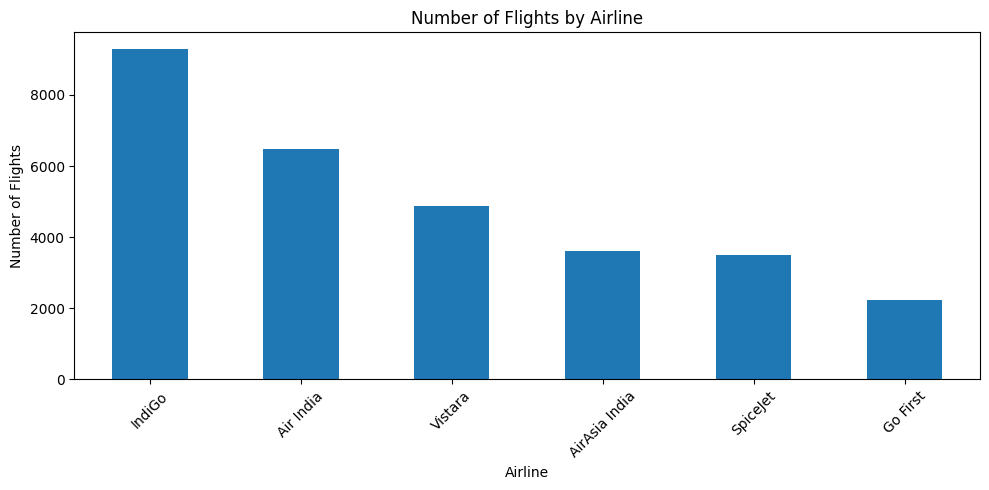

In [176]:
plt.figure(figsize=(10, 5))
cleaned_airline_flight["Airline"].value_counts().plot(kind="bar")
plt.title("Number of Flights by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 9.2 Fare Distribution

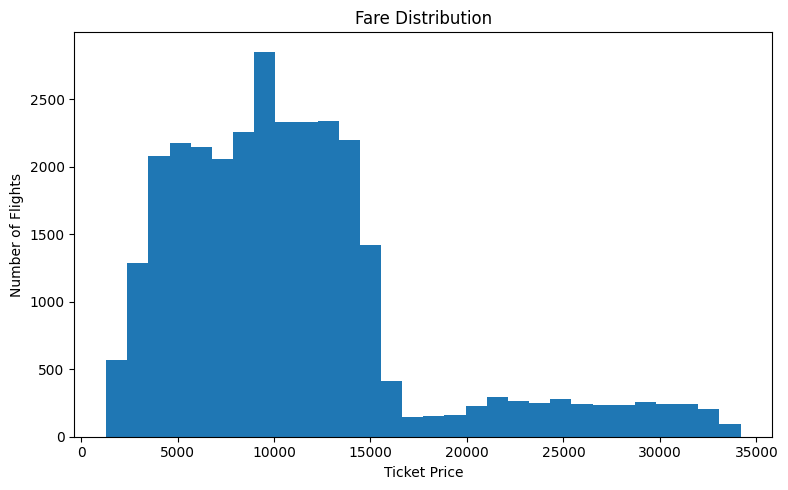

In [177]:
plt.figure(figsize=(8, 5))
plt.hist(cleaned_airline_flight["Ticket_Price"].dropna(), bins=30)
plt.title("Fare Distribution")
plt.xlabel("Ticket Price")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

### 9.3 Class Distribution (Pie Chart)


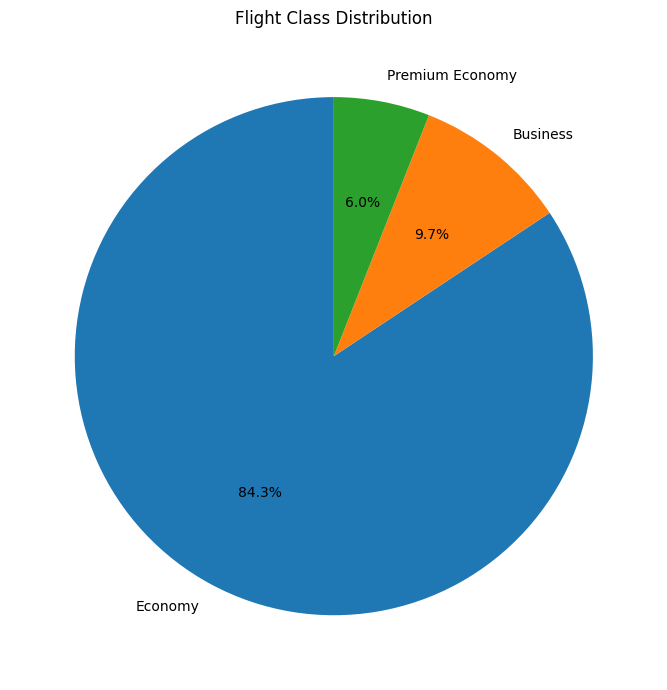

In [178]:
class_counts = cleaned_airline_flight["Class"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Flight Class Distribution")
plt.tight_layout()
plt.show()


### 9.4 Ticket Price by Number of Stops (Box Plot)


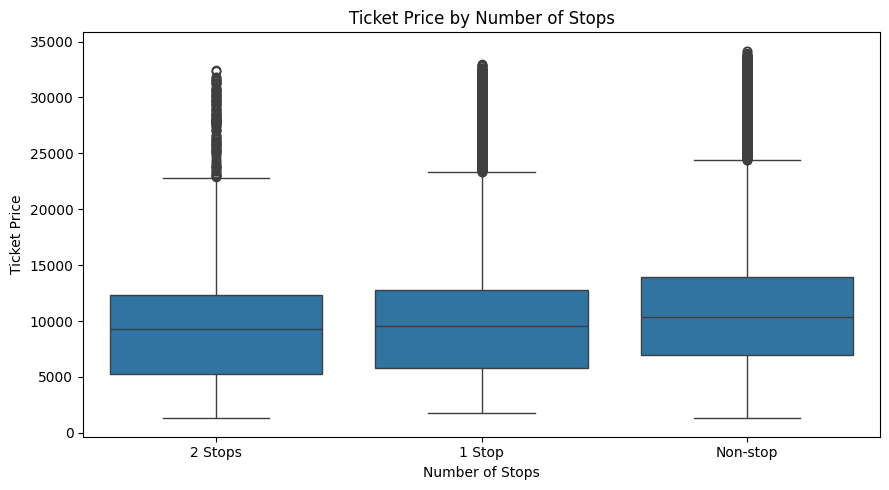

In [179]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=cleaned_airline_flight,
    x="Total_Stops",
    y="Ticket_Price"
)
plt.title("Ticket Price by Number of Stops")
plt.xlabel("Number of Stops")
plt.ylabel("Ticket Price")
plt.tight_layout()
plt.show()


### 9.5 Ticket Price vs Flight Duration (Scatter Plot)


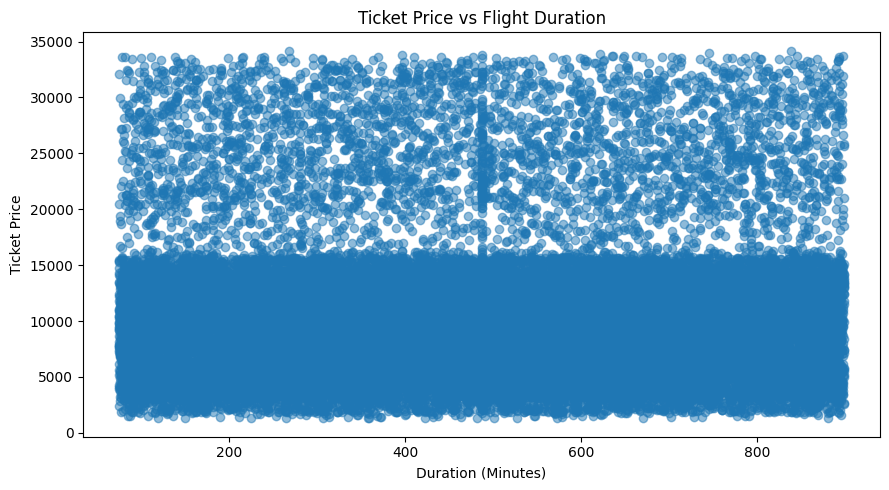

In [180]:
plt.figure(figsize=(9, 5))
plt.scatter(
    cleaned_airline_flight["Duration_Minutes"],
    cleaned_airline_flight["Ticket_Price"],
    alpha=0.5
)
plt.title("Ticket Price vs Flight Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Ticket Price")
plt.tight_layout()
plt.show()


### 9.6 Correlation Heatmap


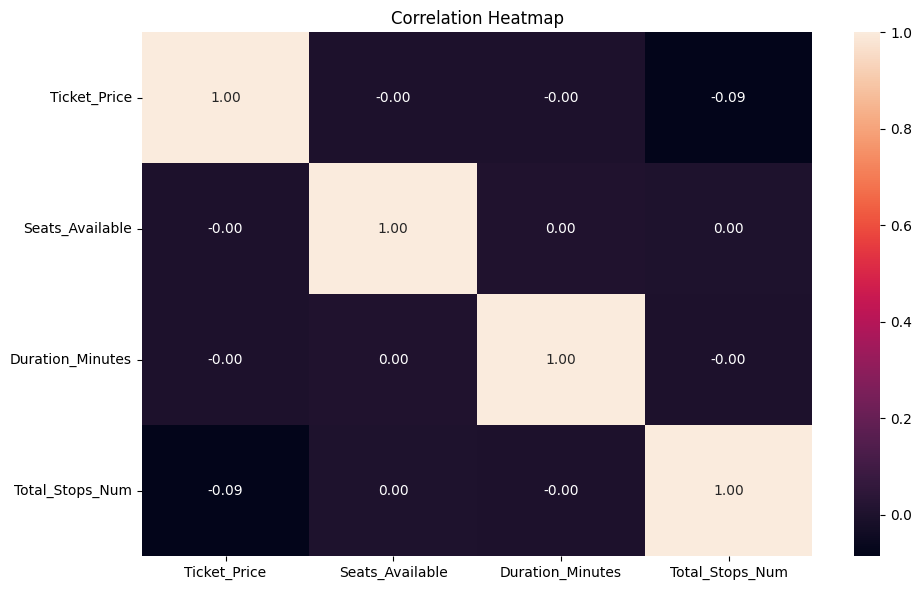

In [181]:
numeric_data = cleaned_airline_flight.select_dtypes(include=np.number)

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 10. Final Python Validation

In [182]:
print("Final Shape:", cleaned_airline_flight.shape)
print("Total Missing Values:", cleaned_airline_flight.isnull().sum().sum())
print("Total Duplicate Rows:", cleaned_airline_flight.duplicated().sum())

Final Shape: (30000, 20)
Total Missing Values: 451
Total Duplicate Rows: 300
